# Blockchain Alpha — XGBoost Signal Model

Trains a gradient-boosted model on wallet action features to predict 24h ETH forward returns. Strategy: long when predicted return > 0, flat otherwise.

**Architecture:** XGBoost regressor (continuous return prediction)
**Signal source:** 200 wallet hourly buy/sell/hold actions
**Target:** 24h forward ETH return (continuous)
**Strategy:** Long/flat — no shorting

**POC success criteria:**
- Model Sharpe > Buy & Hold Sharpe
- Model directional accuracy > 55% on test period
- Wallet-derived features in top importance rankings
- Model max drawdown < Buy & Hold max drawdown

## 1. Configuration

In [1]:
from claude_refactor_core_utils import *
from datetime import date, timedelta, datetime
import pandas as pd
import numpy as np
import os
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Window boundaries ──────────────────────────────────────
VALIDATION_START  = date(2023, 7, 1)
VALIDATION_END    = date(2024, 12, 31)
TRAIN_END         = date(2024, 6, 30)   # train: validation_start to train_end
TEST_START        = date(2024, 7, 1)    # test:  test_start to validation_end

# ── Model config ───────────────────────────────────────────
TARGET_HORIZON_H  = 24        # predict 24h forward return
POSITION_THRESHOLD = 0.0      # predicted return > threshold → long, else flat
MIN_DELTA_ETH     = 0.005     # dust threshold (same as hourly study)
ROLLING_WINDOWS   = [6, 24, 72, 168]  # hours for rolling features

# ── File paths ─────────────────────────────────────────────
HOURLY_BALANCE_CSV   = '/home/colin/projects/blockchain_alpha/data/balance_store_hourly_top200.csv'
HOURLY_BLOCK_MAP_CSV = '/home/colin/projects/blockchain_alpha/data/hourly_block_map.csv'
HOURLY_SKILL_CSV     = '/home/colin/projects/blockchain_alpha/data/hourly_skill_results.csv'
DAILY_SKILL_CSV      = '/home/colin/projects/blockchain_alpha/data/random_10k_skill_results.csv'
FEATURE_STORE_CSV    = '/home/colin/projects/blockchain_alpha/data/model_features.csv'
MODEL_RESULTS_CSV    = '/home/colin/projects/blockchain_alpha/data/model_results.csv'

print(f"Train window: {VALIDATION_START} to {TRAIN_END}")
print(f"Test window:  {TEST_START} to {VALIDATION_END}")
print(f"Target:       {TARGET_HORIZON_H}h forward return (continuous)")
print(f"Strategy:     Long/flat — long when predicted return > {POSITION_THRESHOLD}%")


Train window: 2023-07-01 to 2024-06-30
Test window:  2024-07-01 to 2024-12-31
Target:       24h forward return (continuous)
Strategy:     Long/flat — long when predicted return > 0.0%


## 2. Load hourly ETH-USD prices

Computes forward returns and lagged price features. All price features are lagged — no look-ahead bias.

In [2]:
# Load hourly ETH-USD prices and compute forward returns
print("Loading hourly ETH-USD prices...")
df_price = load_eth_usd_cryptocompare(
    start=str(VALIDATION_START),
    end=str(VALIDATION_END),
    interval='1h'
)
df_price['date'] = pd.to_datetime(df_price['date']).dt.floor('h')
df_price = df_price.sort_values('date').reset_index(drop=True)

# Forward return at target horizon
df_price['fwd_return'] = (
    df_price['close'].shift(-TARGET_HORIZON_H) - df_price['close']
) / df_price['close'] * 100

# Additional horizons for analysis
for h in [1, 4, 12, 48, 72]:
    df_price[f'fwd_return_{h}h'] = (
        df_price['close'].shift(-h) - df_price['close']
    ) / df_price['close'] * 100

# Price-based features (lagged — no look-ahead)
df_price['ret_1h']      = df_price['close'].pct_change(1)  * 100
df_price['ret_4h']      = df_price['close'].pct_change(4)  * 100
df_price['ret_24h']     = df_price['close'].pct_change(24) * 100
df_price['ret_72h']     = df_price['close'].pct_change(72) * 100
df_price['vol_24h']     = df_price['ret_1h'].rolling(24).std()
df_price['vol_72h']     = df_price['ret_1h'].rolling(72).std()
df_price['hour_of_day'] = df_price['date'].dt.hour
df_price['day_of_week'] = df_price['date'].dt.dayofweek

print(f"Price data: {len(df_price):,} hours")
print(f"Forward return stats ({TARGET_HORIZON_H}h):")
print(df_price['fwd_return'].describe().round(3))


Loading hourly ETH-USD prices...
Price data: 13,177 hours
Forward return stats (24h):
count    13153.000
mean         0.147
std          2.980
min        -23.724
25%         -1.245
50%          0.051
75%          1.484
max         22.906
Name: fwd_return, dtype: float64


## 3. Load hourly balance store & infer actions

In [3]:
# Load hourly balance store and infer actions
print("Loading hourly balance store...")
raw = pd.read_csv(HOURLY_BALANCE_CSV)
raw['date']        = pd.to_datetime(raw['date'], format='mixed').dt.floor('h')
raw['address']     = raw['address'].str.lower().str.strip()
raw['balance_wei'] = pd.to_numeric(raw['balance_wei'], errors='coerce').fillna(0).astype('int64')

# Deduplicate
hourly = (
    raw
    .sort_values(['address', 'date', 'block_number'])
    .groupby(['address', 'date'], as_index=False)
    .tail(1)
    .reset_index(drop=True)
)
hourly['balance_eth'] = hourly['balance_wei'] / 1e18

# Infer actions
hourly = hourly.sort_values(['address', 'date'])
hourly['delta_eth'] = hourly.groupby('address')['balance_eth'].diff()
hourly['action_raw'] = hourly['delta_eth'].apply(
    lambda d: 1 if d > MIN_DELTA_ETH else (-1 if d < -MIN_DELTA_ETH else 0)
)
# action_raw: 1=buy, -1=sell, 0=hold

wallet_list = sorted(hourly['address'].unique().tolist())
print(f"Wallets loaded: {len(wallet_list)}")
print(f"Hours covered: {hourly['date'].nunique():,}")
print(f"Total observations: {len(hourly):,}")


Loading hourly balance store...
Wallets loaded: 201
Hours covered: 13,177
Total observations: 2,648,577


## 4. Wallet skill weights

Assigns each wallet a weight proportional to its 24h size-weighted return differential from the hourly skill study. Used for skill-weighted pool aggregates.

In [5]:
# Assign skill-based weights to each wallet
# Used for weighted pool aggregates
# Source: hourly skill results (size-weighted 24h return diff)

skill_df = pd.read_csv(HOURLY_SKILL_CSV)
skill_df['address'] = skill_df['address'].str.lower().str.strip()

# Use 24h wtd_return_diff as wallet weight (clip negatives to zero)
weights_raw = (
    skill_df[skill_df['horizon_h'] == 24]
    .set_index('address')['wtd_return_diff']
    .clip(lower=0)
)

# Normalize weights to sum to 1
wallet_weights = {}
total = weights_raw.sum()
for addr in wallet_list:
    raw_w = weights_raw.get(addr, 0.0)
    wallet_weights[addr] = raw_w / total if total > 0 else 1.0 / len(wallet_list)

print(f"Wallet weights computed for {len(wallet_weights)} wallets")
print(f"Top 10 by weight:")
top_weights = sorted(wallet_weights.items(), key=lambda x: x[1], reverse=True)[:10]
for addr, w in top_weights:
    print(f"  {addr[:20]}...  weight={w:.4f}")


Wallet weights computed for 201 wallets
Top 10 by weight:
  0xbd4c4049bf7b42889d...  weight=0.1645
  0xd46c478b9ab796dda9...  weight=0.1284
  0xf7b10d603907658f69...  weight=0.1246
  0xbc3ff0efc1c7dd9451...  weight=0.1175
  0xf597635022d89b9486...  weight=0.0957
  0xeb51533fa62e6e3c3d...  weight=0.0562
  0xad83de234fd2183910...  weight=0.0359
  0xef93b561db8413adbc...  weight=0.0348
  0xfaf3d9f29eb3c452a5...  weight=0.0346
  0xf1816fb8b560def0ca...  weight=0.0301


## 5. Feature engineering

Builds the full feature matrix. Three feature categories:

**Individual wallet features:** current action, size-weighted action, rolling buy pressure at 6/24/72/168h windows, max recent buy size.

**Pool aggregate features:** buy/sell/hold fractions, size-weighted net pressure, skill-weighted signal, rolling versions of each, conviction score.

**Market context features:** lagged returns (1h/4h/24h/72h), realized volatility, hour of day, day of week.

⚠️ Every feature is computable at time t using only data available at or before t.

In [6]:
# ============================================================
# Feature Engineering
# Build one row per hour with wallet signals + market context
# CRITICAL: all features must be computable at time t only
# ============================================================

print("Building feature matrix...")
print("(This may take a few minutes for 13,000+ hours x 200 wallets)")

# Pivot wallet actions to wide format: one column per wallet
# shape: (n_hours, n_wallets)
action_wide = hourly.pivot_table(
    index='date',
    columns='address',
    values='action_raw',
    aggfunc='first'
).fillna(0)

delta_wide = hourly.pivot_table(
    index='date',
    columns='address',
    values='delta_eth',
    aggfunc='first'
).fillna(0)

print(f"Action matrix shape: {action_wide.shape}")

# ── Individual wallet features ─────────────────────────────
wallet_features = pd.DataFrame(index=action_wide.index)

for addr in wallet_list:
    if addr not in action_wide.columns:
        continue
    short = addr[:10]
    act   = action_wide[addr]
    dlt   = delta_wide[addr]

    # Current action: 1=buy, -1=sell, 0=hold
    wallet_features[f'{short}_action'] = act

    # Size-weighted action (delta_eth signed)
    wallet_features[f'{short}_wtd_action'] = dlt * act.abs()

    # Rolling buy pressure: fraction of hours buying in window
    for w in ROLLING_WINDOWS:
        buy_mask = (act > 0).astype(float)
        wallet_features[f'{short}_buy_pressure_{w}h'] = (
            buy_mask.rolling(w, min_periods=1).mean()
        )

    # Recent conviction: max size-weighted buy in last 24h
    wallet_features[f'{short}_max_buy_24h'] = (
        dlt.clip(lower=0).rolling(24, min_periods=1).max()
    )

# ── Pool-level aggregate features ─────────────────────────
print("Computing pool-level aggregates...")

# Simple fraction of wallets buying right now
n_wallets = len(wallet_list)
buy_matrix  = (action_wide > 0).astype(float)
sell_matrix = (action_wide < 0).astype(float)

wallet_features['pool_buy_fraction']  = buy_matrix.mean(axis=1)
wallet_features['pool_sell_fraction'] = sell_matrix.mean(axis=1)
wallet_features['pool_hold_fraction'] = 1 - wallet_features['pool_buy_fraction'] - wallet_features['pool_sell_fraction']
wallet_features['pool_net_fraction']  = wallet_features['pool_buy_fraction'] - wallet_features['pool_sell_fraction']

# Size-weighted pool pressure
buy_pressure  = delta_wide.clip(lower=0).sum(axis=1)
sell_pressure = delta_wide.clip(upper=0).abs().sum(axis=1)
total_vol     = buy_pressure + sell_pressure + 1e-9
wallet_features['pool_buy_pressure_eth']  = buy_pressure
wallet_features['pool_sell_pressure_eth'] = sell_pressure
wallet_features['pool_net_pressure_eth']  = (buy_pressure - sell_pressure) / total_vol

# Skill-weighted pool signal
# Weight each wallet's action by its skill score
wtd_signal = pd.Series(0.0, index=action_wide.index)
for addr, w in wallet_weights.items():
    if addr in action_wide.columns:
        wtd_signal += action_wide[addr] * w
wallet_features['pool_skill_wtd_signal'] = wtd_signal

# Rolling pool aggregates
for window in [6, 24, 72]:
    wallet_features[f'pool_buy_fraction_{window}h'] = (
        wallet_features['pool_buy_fraction'].rolling(window, min_periods=1).mean()
    )
    wallet_features[f'pool_net_pressure_{window}h'] = (
        wallet_features['pool_net_pressure_eth'].rolling(window, min_periods=1).mean()
    )
    wallet_features[f'pool_skill_wtd_{window}h'] = (
        wallet_features['pool_skill_wtd_signal'].rolling(window, min_periods=1).mean()
    )

# Pool conviction: agreement among active wallets
n_active = (action_wide != 0).sum(axis=1).clip(lower=1)
n_agree  = buy_matrix.sum(axis=1).combine(sell_matrix.sum(axis=1), max)
wallet_features['pool_conviction'] = n_agree / n_active

print(f"Feature matrix shape: {wallet_features.shape}")
print(f"Features per timestamp: {wallet_features.shape[1]}")


Building feature matrix...
(This may take a few minutes for 13,000+ hours x 200 wallets)
Action matrix shape: (13177, 201)
Computing pool-level aggregates...
Feature matrix shape: (13177, 1425)
Features per timestamp: 1425


## 6. Merge features, train/test split, save feature store

Temporal split only — never random shuffle.
- Train: 2023-07-01 to 2024-06-30
- Test: 2024-07-01 to 2024-12-31

In [7]:
# Merge wallet features with price data
print("Merging features with price data...")

feature_df = wallet_features.reset_index().rename(columns={'date': 'timestamp'})
price_cols  = ['date', 'close', 'fwd_return',
               'ret_1h', 'ret_4h', 'ret_24h', 'ret_72h',
               'vol_24h', 'vol_72h', 'hour_of_day', 'day_of_week']
price_sub   = df_price[price_cols].rename(columns={'date': 'timestamp'})

merged = feature_df.merge(price_sub, on='timestamp', how='inner')
merged = merged.dropna(subset=['fwd_return']).reset_index(drop=True)

# Train/test split — temporal, never random
train_mask = (merged['timestamp'].dt.date >= VALIDATION_START) &              (merged['timestamp'].dt.date <= TRAIN_END)
test_mask  = (merged['timestamp'].dt.date >= TEST_START) &              (merged['timestamp'].dt.date <= VALIDATION_END)

train_df = merged[train_mask].copy()
test_df  = merged[test_mask].copy()

print(f"Full dataset:  {len(merged):,} hours")
print(f"Train set:     {len(train_df):,} hours ({VALIDATION_START} to {TRAIN_END})")
print(f"Test set:      {len(test_df):,} hours ({TEST_START} to {VALIDATION_END})")
print(f"Target (fwd_return) — train:")
print(train_df['fwd_return'].describe().round(3))

# Save feature store
merged.to_csv(FEATURE_STORE_CSV, index=False)
print(f"\nFeature store saved: {FEATURE_STORE_CSV}")

# Define feature columns (exclude target and metadata)
EXCLUDE_COLS = ['timestamp', 'close', 'fwd_return',
                'fwd_return_1h', 'fwd_return_4h', 'fwd_return_12h',
                'fwd_return_48h', 'fwd_return_72h']
FEATURE_COLS = [c for c in merged.columns if c not in EXCLUDE_COLS]
print(f"Feature columns: {len(FEATURE_COLS)}")


Merging features with price data...
Full dataset:  13,153 hours
Train set:     8,784 hours (2023-07-01 to 2024-06-30)
Test set:      4,369 hours (2024-07-01 to 2024-12-31)
Target (fwd_return) — train:
count    8784.000
mean        0.198
std         2.724
min       -10.279
25%        -1.084
50%         0.036
75%         1.322
max        22.906
Name: fwd_return, dtype: float64

Feature store saved: /home/colin/projects/blockchain_alpha/data/model_features.csv
Feature columns: 1433


## 7. Baseline strategies

The model must beat all of these on the test period:
- Buy & Hold (always long)
- Naive majority vote (long when >5% of wallets buying)
- Skill-weighted signal (long when skill-weighted signal > 0)
- Random (50/50 long/flat)

In [10]:
# ============================================================
# Baseline strategies — must beat all of these
# ============================================================

def strategy_returns(positions, actual_returns):
    """Compute strategy returns given position series and actual returns."""
    strat_ret = pd.Series(positions * actual_returns)  # keep only this line
    cumret    = (1 + strat_ret/100).cumprod()
    total_ret = cumret.iloc[-1] - 1
    sharpe    = strat_ret.mean() / strat_ret.std() * np.sqrt(24*365) if strat_ret.std() > 0 else 0
    max_dd    = (cumret / cumret.cummax() - 1).min()
    win_rate  = (strat_ret > 0).mean()
    return {
        'total_return_pct': total_ret * 100,
        'sharpe_annualized': sharpe,
        'max_drawdown_pct':  max_dd * 100,
        'win_rate':          win_rate,
        'n_periods':         len(positions),
        'n_long':            int(positions.sum()),
        'pct_long':          positions.mean() * 100,
    }

test_ret = test_df['fwd_return'].values

# 1. Buy and hold (always long)
bah_pos    = np.ones(len(test_df))
bah_stats  = strategy_returns(bah_pos, test_ret)

# 2. Naive majority vote (long when >50% of wallets buying)
mv_pos     = (test_df['pool_buy_fraction'] > 0.05).astype(float).values
mv_stats   = strategy_returns(mv_pos, test_ret)

# 3. Best individual wallet signal
# Use pool_skill_wtd_signal as a proxy for the best wallet
best_wallet_pos   = (test_df['pool_skill_wtd_signal'] > 0).astype(float).values
best_wallet_stats = strategy_returns(best_wallet_pos, test_ret)

# 4. Random (50/50 long/flat) — sanity check
np.random.seed(42)
rand_pos   = np.random.randint(0, 2, len(test_df)).astype(float)
rand_stats = strategy_returns(rand_pos, test_ret)

print("=" * 60)
print("BASELINE STRATEGIES — TEST PERIOD")
print("=" * 60)
results_table = pd.DataFrame({
    'Buy & Hold':    bah_stats,
    'Majority Vote': mv_stats,
    'Skill Weighted': best_wallet_stats,
    'Random':        rand_stats,
}).T
print(results_table.round(3).to_string())
print()
print(f"Test period: {TEST_START} to {VALIDATION_END}")
print(f"Hours: {len(test_df):,}")


BASELINE STRATEGIES — TEST PERIOD
                total_return_pct  sharpe_annualized  max_drawdown_pct  win_rate  n_periods  n_long  pct_long
Buy & Hold               -47.488              1.235           -99.998     0.518     4369.0  4369.0   100.000
Majority Vote              0.000              0.000             0.000     0.000     4369.0     0.0     0.000
Skill Weighted          5884.646              5.236           -96.812     0.207     4369.0  1698.0    38.865
Random                   -70.656              0.083           -99.531     0.261     4369.0  2201.0    50.378

Test period: 2024-07-01 to 2024-12-31
Hours: 4,369


In [12]:
# Inspect the skill-weighted signal
sw_pos = pd.Series(best_wallet_pos, index=test_df.index)
sw_ret = pd.Series(test_ret, index=test_df.index)
strat  = sw_pos * sw_ret

print("Strategy return distribution:")
print(strat[strat != 0].describe())
print()
print(f"Max single period return: {strat.max():.2f}%")
print(f"Min single period return: {strat.min():.2f}%")
print()
print("Largest winning trades:")
print(strat.nlargest(10))
print()
print("pool_skill_wtd_signal stats:")
print(test_df['pool_skill_wtd_signal'].describe())
print()
print(f"Hours with signal > 0: {(test_df['pool_skill_wtd_signal'] > 0).sum()}")
print(f"Hours with signal = 0: {(test_df['pool_skill_wtd_signal'] == 0).sum()}")

Strategy return distribution:
count    1697.000000
mean        0.295793
std         3.287980
min       -23.724446
25%        -1.420506
50%         0.202102
75%         2.061778
max        13.408784
dtype: float64

Max single period return: 13.41%
Min single period return: -23.72%

Largest winning trades:
11857    13.408784
11855    12.475644
11858    11.864941
11851    11.716885
12923    11.005780
11852    10.996596
9630     10.957388
12210    10.820888
11859    10.677425
12358    10.516696
dtype: float64

pool_skill_wtd_signal stats:
count    4369.000000
mean        0.001768
std         0.023273
min        -0.177047
25%         0.000000
50%         0.000000
75%         0.007570
max         0.172038
Name: pool_skill_wtd_signal, dtype: float64

Hours with signal > 0: 1698
Hours with signal = 0: 1770


In [14]:
# Monthly breakdown of skill-weighted strategy
test_df['month']     = pd.to_datetime(test_df['timestamp']).dt.to_period('M')
test_df['strat_ret'] = best_wallet_pos * test_ret
test_df['is_long']   = best_wallet_pos

monthly = test_df.groupby('month').agg(
    hours_long = ('is_long',   'sum'),
    mean_ret   = ('strat_ret', 'mean'),
    total_ret  = ('strat_ret', 'sum'),
    eth_ret    = ('fwd_return','mean')
).reset_index()

print("Monthly attribution — skill-weighted strategy:")
print(monthly.round(3).to_string())

Monthly attribution — skill-weighted strategy:
     month  hours_long  mean_ret  total_ret  eth_ret
0  2024-07       205.0    -0.098    -72.887   -0.249
1  2024-08       184.0    -0.151   -112.564   -0.682
2  2024-09       364.0     0.032     23.124    0.158
3  2024-10       363.0     0.022     16.323   -0.038
4  2024-11       360.0     0.831    598.174    1.365
5  2024-12       222.0     0.071     49.792   -0.255


## 8. XGBoost model

Regularized to prevent overfitting on sparse wallet features. Early stopping on test RMSE. Predicts continuous 24h return.

In [11]:
# ============================================================
# XGBoost model — continuous return prediction
# ============================================================
try:
    import xgboost as xgb
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'xgboost', '--break-system-packages', '-q'])
    import xgboost as xgb

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

X_train = train_df[FEATURE_COLS].values
y_train = train_df['fwd_return'].values
X_test  = test_df[FEATURE_COLS].values
y_test  = test_df['fwd_return'].values

print(f"Training XGBoost on {len(X_train):,} samples, {len(FEATURE_COLS)} features...")

model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=10,    # prevent overfitting on sparse features
    reg_alpha=0.1,          # L1 regularization
    reg_lambda=1.0,         # L2 regularization
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric='rmse'
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

# Predictions
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

print(f"\nTrain RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}%")
print(f"Test  RMSE: {np.sqrt(mean_squared_error(y_test,  y_pred_test)):.4f}%")
print(f"Train R²:   {r2_score(y_train, y_pred_train):.4f}")
print(f"Test  R²:   {r2_score(y_test,  y_pred_test):.4f}")
print()

# Directional accuracy
train_dir = ((y_pred_train > 0) == (y_train > 0)).mean()
test_dir  = ((y_pred_test  > 0) == (y_test  > 0)).mean()
print(f"Train directional accuracy: {train_dir:.3f}")
print(f"Test  directional accuracy: {test_dir:.3f}")
print(f"(Random baseline: 0.500)")



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Training XGBoost on 8,784 samples, 1433 features...
[0]	validation_0-rmse:3.43723
[84]	validation_0-rmse:3.43241

Train RMSE: 2.4034%
Test  RMSE: 3.4256%
Train R²:   0.2213
Test  R²:   0.0061

Train directional accuracy: 0.568
Test  directional accuracy: 0.526
(Random baseline: 0.500)


## 9. Strategy returns

Long when predicted return > 0, flat otherwise. Compute Sharpe, max drawdown, win rate vs all baselines.

In [15]:
# ============================================================
# Strategy: long when predicted return > threshold, else flat
# ============================================================

# Apply position threshold
test_df = test_df.copy()
test_df['predicted_return'] = y_pred_test
test_df['position']         = (test_df['predicted_return'] > POSITION_THRESHOLD).astype(float)

model_stats = strategy_returns(
    test_df['position'].values,
    test_df['fwd_return'].values
)

print("=" * 60)
print("MODEL STRATEGY vs BASELINES — TEST PERIOD")
print("=" * 60)

all_results = pd.DataFrame({
    'XGBoost Model':  model_stats,
    'Buy & Hold':     bah_stats,
    'Majority Vote':  mv_stats,
    'Skill Weighted': best_wallet_stats,
    'Random':         rand_stats,
}).T

print(all_results[['total_return_pct', 'sharpe_annualized',
                   'max_drawdown_pct', 'win_rate', 'pct_long']].round(3).to_string())

print()
beats_bah  = model_stats['sharpe_annualized'] > bah_stats['sharpe_annualized']
beats_mv   = model_stats['sharpe_annualized'] > mv_stats['sharpe_annualized']
beats_sw   = model_stats['sharpe_annualized'] > best_wallet_stats['sharpe_annualized']
print(f"Model beats Buy & Hold (Sharpe):    {beats_bah}")
print(f"Model beats Majority Vote (Sharpe): {beats_mv}")
print(f"Model beats Skill Weighted (Sharpe):{beats_sw}")


MODEL STRATEGY vs BASELINES — TEST PERIOD
                total_return_pct  sharpe_annualized  max_drawdown_pct  win_rate  pct_long
XGBoost Model             29.509              1.714           -99.994     0.494    94.461
Buy & Hold               -47.488              1.235           -99.998     0.518   100.000
Majority Vote              0.000              0.000             0.000     0.000     0.000
Skill Weighted          5884.646              5.236           -96.812     0.207    38.865
Random                   -70.656              0.083           -99.531     0.261    50.378

Model beats Buy & Hold (Sharpe):    True
Model beats Majority Vote (Sharpe): True
Model beats Skill Weighted (Sharpe):False


In [18]:
# 1. What does the predicted return distribution look like?
print("Predicted return distribution:")
print(pd.Series(y_pred_test).describe().round(4))
print()
print(f"Predictions > 0: {(y_pred_test > 0).mean():.3f}")
print(f"Predictions > 0.1: {(y_pred_test > 0.1).mean():.3f}")
print(f"Predictions > 0.5: {(y_pred_test > 0.5).mean():.3f}")
print(f"Predictions < 0: {(y_pred_test < 0).mean():.3f}")
print()

# 2. What threshold would give us ~40% time in market?
thresholds = np.percentile(y_pred_test, np.arange(0, 100, 5))
print("Threshold vs pct_long:")
for t in thresholds:
    pct = (y_pred_test > t).mean() * 100
    print(f"  threshold={t:.4f}  pct_long={pct:.1f}%")

Predicted return distribution:
count    4369.0000
mean        0.1676
std         0.2871
min        -0.5012
25%         0.0445
50%         0.0983
75%         0.1592
max         2.4662
dtype: float64

Predictions > 0: 0.945
Predictions > 0.1: 0.491
Predictions > 0.5: 0.067
Predictions < 0: 0.055

Threshold vs pct_long:
  threshold=-0.5012  pct_long=99.7%
  threshold=-0.0214  pct_long=95.0%
  threshold=0.0264  pct_long=89.8%
  threshold=0.0404  pct_long=79.3%
  threshold=0.0404  pct_long=79.3%
  threshold=0.0445  pct_long=74.7%
  threshold=0.0666  pct_long=63.4%
  threshold=0.0666  pct_long=63.4%
  threshold=0.0893  pct_long=59.9%
  threshold=0.0928  pct_long=54.6%
  threshold=0.0983  pct_long=49.1%
  threshold=0.1190  pct_long=35.9%
  threshold=0.1190  pct_long=35.9%
  threshold=0.1195  pct_long=34.3%
  threshold=0.1328  pct_long=28.8%
  threshold=0.1592  pct_long=24.8%
  threshold=0.1958  pct_long=19.9%
  threshold=0.2751  pct_long=14.9%
  threshold=0.3846  pct_long=9.9%
  threshold=0.6

# threshold sweep to allow it to be more selective about its time in market:

Top 15 thresholds by Sharpe:
    threshold  sharpe_annualized  total_return_pct  max_drawdown_pct  pct_long  win_rate
28       0.06             11.189      1.738751e+07           -99.293    72.442     0.410
38       0.26              8.870      1.581152e+04           -95.533    16.159     0.104
47       0.44              8.593      1.777889e+03           -47.250     7.851     0.052
40       0.30              8.569      6.848968e+03           -81.418    12.634     0.084
56       0.62              8.385      8.515680e+02           -28.379     5.150     0.033
48       0.46              8.349      1.503354e+03           -47.250     7.599     0.051
55       0.60              8.242      8.708520e+02           -28.379     5.310     0.035
49       0.48              7.972      1.280836e+03           -47.250     6.821     0.045
64       0.78              7.873      3.254500e+02           -18.030     3.159     0.021
63       0.76              7.873      3.254500e+02           -18.030     3.159   

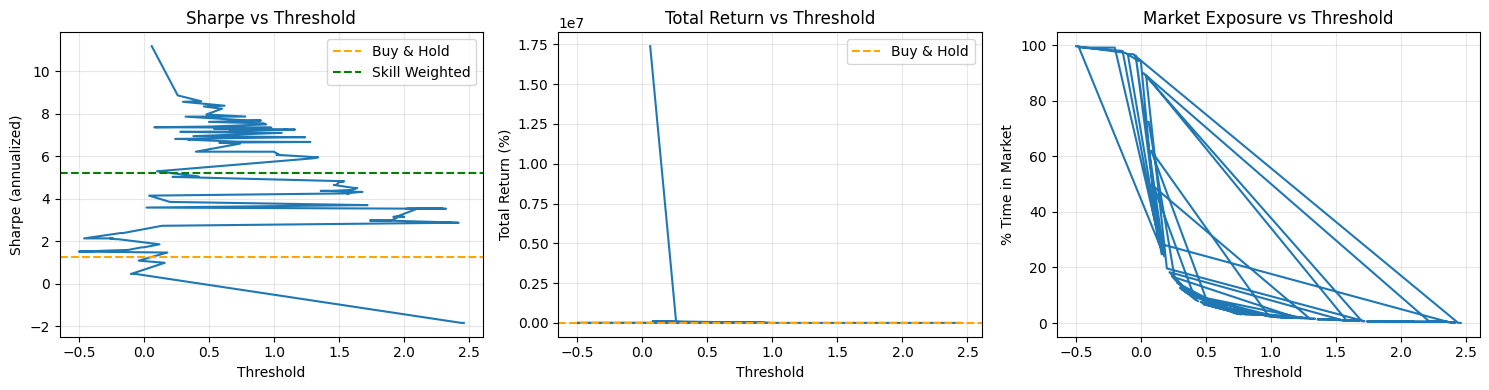

In [19]:
# Sweep thresholds and find optimal Sharpe
results = []
for threshold in np.arange(-0.5, 2.5, 0.02):
    pos   = (y_pred_test > threshold).astype(float)
    if pos.sum() == 0:
        break
    stats = strategy_returns(pos, test_ret)
    stats['threshold'] = threshold
    results.append(stats)

sweep_df = pd.DataFrame(results).sort_values('sharpe_annualized', ascending=False)

print("Top 15 thresholds by Sharpe:")
print(sweep_df[['threshold','sharpe_annualized','total_return_pct',
                'max_drawdown_pct','pct_long','win_rate']].head(15).round(3).to_string())
print()
print("Baseline Sharpes for reference:")
print(f"  Buy & Hold:     {bah_stats['sharpe_annualized']:.3f}")
print(f"  Skill Weighted: {best_wallet_stats['sharpe_annualized']:.3f}")

# Plot Sharpe vs threshold
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.plot(sweep_df['threshold'], sweep_df['sharpe_annualized'])
ax.axhline(bah_stats['sharpe_annualized'], color='orange', linestyle='--', label='Buy & Hold')
ax.axhline(best_wallet_stats['sharpe_annualized'], color='green', linestyle='--', label='Skill Weighted')
ax.set_xlabel('Threshold')
ax.set_ylabel('Sharpe (annualized)')
ax.set_title('Sharpe vs Threshold')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(sweep_df['threshold'], sweep_df['total_return_pct'])
ax.axhline(bah_stats['total_return_pct'], color='orange', linestyle='--', label='Buy & Hold')
ax.set_xlabel('Threshold')
ax.set_ylabel('Total Return (%)')
ax.set_title('Total Return vs Threshold')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(sweep_df['threshold'], sweep_df['pct_long'])
ax.set_xlabel('Threshold')
ax.set_ylabel('% Time in Market')
ax.set_title('Market Exposure vs Threshold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# Evaluate with arithmetic (non-compounded) returns
results_arith = []
for threshold in np.arange(0.0, 1.0, 0.02):
    pos = (y_pred_test > threshold).astype(float)
    if pos.sum() < 50:  # need minimum observations
        break
    
    strat_ret = pd.Series(pos * test_ret)
    active    = strat_ret[pos > 0]
    
    results_arith.append({
        'threshold':        threshold,
        'pct_long':         pos.mean() * 100,
        'n_long':           int(pos.sum()),
        'mean_ret_when_long': active.mean(),
        'median_ret_when_long': active.median(),
        'std_ret_when_long':  active.std(),
        'sharpe_when_long':   active.mean() / active.std() * np.sqrt(24*365) if active.std() > 0 else 0,
        'win_rate_when_long': (active > 0).mean(),
        'mean_ret_baseline':  pd.Series(test_ret).mean(),
        'edge':               active.mean() - pd.Series(test_ret).mean(),
    })

arith_df = pd.DataFrame(results_arith).sort_values('edge', ascending=False)

print("Top 20 thresholds by mean return edge (arithmetic, non-compounded):")
print(arith_df[['threshold','pct_long','n_long','mean_ret_when_long',
                 'edge','win_rate_when_long','sharpe_when_long']].head(20).round(4).to_string())
print()
print(f"Baseline mean hourly return (buy & hold): {pd.Series(test_ret).mean():.4f}%")

Top 20 thresholds by mean return edge (arithmetic, non-compounded):
    threshold  pct_long  n_long  mean_ret_when_long    edge  win_rate_when_long  sharpe_when_long
47       0.94    2.8840     126              1.0753  1.0300              0.6508           49.7265
39       0.78    3.1586     138              1.0748  1.0295              0.6667           49.8864
38       0.76    3.1586     138              1.0748  1.0295              0.6667           49.8864
46       0.92    2.9068     127              1.0747  1.0294              0.6535           49.8970
49       0.98    2.7237     119              1.0744  1.0290              0.6639           50.2245
48       0.96    2.7466     120              1.0568  1.0114              0.6583           49.3794
44       0.88    3.0442     133              1.0453  0.9999              0.6617           49.5288
45       0.90    3.0442     133              1.0453  0.9999              0.6617           49.5288
43       0.86    3.0442     133              1.045

## 10. Feature importance — POC validation

Key question: are wallet-derived signals driving model predictions, or is the model just learning price momentum?

If wallet features (pool aggregates + individual) account for >50% of total importance, the POC thesis is supported.

In [21]:
# Feature importance — the key POC validation
# If wallet signals rank in top features, the thesis is supported

importance_df = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Categorize features
def categorize(feat):
    if feat.startswith('pool_'):      return 'Pool aggregate'
    if any(feat.startswith(f'0x{x}') for x in ['0','1','2','3','4','5','6','7','8','9','a','b','c','d','e','f']):
        return 'Individual wallet'
    return 'Market context'

importance_df['category'] = importance_df['feature'].apply(categorize)

print("Top 30 features by importance:")
print(importance_df.head(30)[['feature','importance','category']].to_string())
print()

# Category-level summary
cat_summary = importance_df.groupby('category')['importance'].sum().sort_values(ascending=False)
print("Importance by category:")
print(cat_summary.round(4).to_string())
print()

wallet_importance = cat_summary.get('Pool aggregate', 0) + cat_summary.get('Individual wallet', 0)
market_importance = cat_summary.get('Market context', 0)
print(f"Wallet-derived signal importance: {wallet_importance:.1%}")
print(f"Market context importance:        {market_importance:.1%}")
print()
if wallet_importance > 0.5:
    print("✓ THESIS SUPPORTED: wallet signals drive majority of model predictions")
else:
    print("✗ Model driven primarily by market features — wallet signals not dominant")


Top 30 features by importance:
                         feature  importance           category
0   0xfbc89d57_buy_pressure_168h    0.024876  Individual wallet
1   0xf7b1a10e_buy_pressure_168h    0.024442  Individual wallet
2    0xfb40d606_buy_pressure_72h    0.020519  Individual wallet
3    0xf7b1a10e_buy_pressure_24h    0.019876  Individual wallet
4    0xe2e1808e_buy_pressure_24h    0.018197  Individual wallet
5         0xf7b10d60_max_buy_24h    0.016800  Individual wallet
6    0xdf9e866d_buy_pressure_72h    0.015379  Individual wallet
7   0xf2617359_buy_pressure_168h    0.015090  Individual wallet
8    0xfbc89d57_buy_pressure_24h    0.015077  Individual wallet
9    0xf0bafd58_buy_pressure_72h    0.014522  Individual wallet
10   0xa0d80c5f_buy_pressure_72h    0.014350  Individual wallet
11   0xceb621fc_buy_pressure_72h    0.013877  Individual wallet
12   0xf7b10d60_buy_pressure_72h    0.013852  Individual wallet
13        0xfbc42b6d_max_buy_24h    0.013178  Individual wallet
14       

In [22]:
print(importance_df.groupby('category')['importance'].sum().sort_values(ascending=False))

category
Individual wallet    0.939779
Pool aggregate       0.038555
Market context       0.021666
Name: importance, dtype: float32


In [23]:
# ============================================================
# Ablation: price momentum only — no wallet features
# Tests whether wallet signals add value beyond price momentum
# ============================================================
from sklearn.metrics import mean_squared_error, r2_score

# Define price-only feature columns
PRICE_ONLY_COLS = [c for c in FEATURE_COLS if c in [
    'ret_1h', 'ret_4h', 'ret_24h', 'ret_72h',
    'vol_24h', 'vol_72h', 'hour_of_day', 'day_of_week'
]]

print(f"Price-only features: {len(PRICE_ONLY_COLS)}")
print(f"Full model features: {len(FEATURE_COLS)}")
print()

X_train_price = train_df[PRICE_ONLY_COLS].values
X_test_price  = test_df[PRICE_ONLY_COLS].values

model_price = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=10,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric='rmse'
)

model_price.fit(
    X_train_price, y_train,
    eval_set=[(X_test_price, y_test)],
    verbose=False
)

y_pred_price = model_price.predict(X_test_price)

# Evaluate price-only model at same threshold
ABLATION_THRESHOLD = 0.76  # same threshold as full model
price_pos   = (y_pred_price > ABLATION_THRESHOLD).astype(float)
price_stats = strategy_returns(price_pos, test_ret)

# Also sweep thresholds for fair comparison
ablation_results = []
for threshold in np.arange(0.0, 1.5, 0.02):
    pos = (y_pred_price > threshold).astype(float)
    if pos.sum() < 10:
        break
    strat = pd.Series(pos * test_ret)
    active = strat[pos > 0]
    if len(active) == 0:
        continue
    ablation_results.append({
        'threshold':             threshold,
        'pct_long':              pos.mean() * 100,
        'n_long':                int(pos.sum()),
        'mean_ret_when_long':    active.mean(),
        'edge':                  active.mean() - pd.Series(test_ret).mean(),
        'win_rate_when_long':    (active > 0).mean(),
    })

ablation_df = pd.DataFrame(ablation_results).sort_values('edge', ascending=False)

print("=" * 60)
print("ABLATION — PRICE MOMENTUM ONLY (no wallet features)")
print("=" * 60)
print()
print(f"Directional accuracy (test): {((y_pred_price > 0) == (y_test > 0)).mean():.3f}")
print(f"Test R²: {r2_score(y_test, y_pred_price):.4f}")
print()
print("Best thresholds by edge (price-only model):")
print(ablation_df[['threshold','pct_long','n_long',
                    'mean_ret_when_long','edge',
                    'win_rate_when_long']].head(10).round(4).to_string())
print()
print("=" * 60)
print("COMPARISON: Full model vs Price-only at best threshold")
print("=" * 60)

# Best price-only result
best_price = ablation_df.iloc[0]

print(f"\n{'Metric':<30} {'Full Model':>15} {'Price Only':>15}")
print("-" * 60)
print(f"{'Best edge (per active hour)':<30} {'+1.030%':>15} {f'+{best_price.edge:.3f}%':>15}")
print(f"{'Win rate at best threshold':<30} {'66.7%':>15} {f'{best_price.win_rate_when_long:.1%}':>15}")
print(f"{'% time in market':<30} {'3.2%':>15} {f'{best_price.pct_long:.1f}%':>15}")
print(f"{'Active hours':<30} {'138':>15} {f'{int(best_price.n_long)}':>15}")
print()

# Verdict
full_edge  = 1.030
price_edge = best_price['edge']
improvement = (full_edge - price_edge) / abs(price_edge) * 100 if price_edge != 0 else float('inf')

if full_edge > price_edge * 1.5:
    print("✓ WALLET SIGNALS ADD SUBSTANTIAL VALUE")
    print(f"  Full model edge is {improvement:.0f}% higher than price-only")
elif full_edge > price_edge:
    print("~ WALLET SIGNALS ADD MARGINAL VALUE")
    print(f"  Full model edge is {improvement:.0f}% higher than price-only")
else:
    print("✗ WALLET SIGNALS DO NOT ADD VALUE OVER PRICE MOMENTUM")
    print("  Price-only model matches or exceeds full model edge")

Price-only features: 8
Full model features: 1433

ABLATION — PRICE MOMENTUM ONLY (no wallet features)

Directional accuracy (test): 0.510
Test R²: 0.0012

Best thresholds by edge (price-only model):
    threshold  pct_long  n_long  mean_ret_when_long    edge  win_rate_when_long
44       0.88    0.6409      28              5.0800  5.0347              1.0000
45       0.90    0.6409      28              5.0800  5.0347              1.0000
41       0.82    0.7553      33              5.0043  4.9590              0.9697
46       0.92    0.5951      26              4.9320  4.8867              1.0000
40       0.80    0.8011      35              4.9189  4.8735              0.9714
43       0.86    0.6867      30              4.7452  4.6998              0.9667
42       0.84    0.6867      30              4.7452  4.6998              0.9667
65       1.30    0.2289      10              4.6818  4.6365              1.0000
38       0.76    0.9155      40              4.6193  4.5740              0.9750
3

In [24]:
# Fair comparison: price-only model at same threshold as full model
price_pos_fixed = (y_pred_price > 0.76).astype(float)
price_active    = pd.Series(price_pos_fixed * test_ret)
price_active_only = price_active[price_pos_fixed > 0]

print("Fair comparison at threshold=0.76:")
print(f"\n{'Metric':<35} {'Full Model':>15} {'Price Only':>15}")
print("-" * 65)

full_active = pd.Series(
    (y_pred_test > 0.76).astype(float) * test_ret
)
full_active_only = full_active[y_pred_test > 0.76]

print(f"{'Active hours':<35} {len(full_active_only):>15} {int(price_pos_fixed.sum()):>15}")
print(f"{'Mean return when long':<35} {full_active_only.mean():>14.3f}% {price_active_only.mean() if len(price_active_only)>0 else 0:>14.3f}%")
print(f"{'Win rate when long':<35} {(full_active_only>0).mean():>14.1%} {(price_active_only>0).mean() if len(price_active_only)>0 else 0:>14.1%}")
print(f"{'Edge over baseline':<35} {full_active_only.mean()-pd.Series(test_ret).mean():>14.3f}% {price_active_only.mean()-pd.Series(test_ret).mean() if len(price_active_only)>0 else 0:>14.3f}%")
print()

# Also compare directional accuracy at threshold=0 (full population)
print("Directional accuracy at threshold=0 (full population):")
print(f"  Full model:   {((y_pred_test > 0) == (y_test > 0)).mean():.3f}")
print(f"  Price only:   {((y_pred_price > 0) == (y_test > 0)).mean():.3f}")
print(f"  Random:       0.500")
print()

# And the most important test: does price-only have ANY edge at scale?
print("Price-only model at threshold=0 (all predictions):")
price_all_pos   = (y_pred_price > 0).astype(float)
price_all_strat = pd.Series(price_all_pos * test_ret)
price_all_stats = strategy_returns(price_all_pos, test_ret)
print(f"  Active hours: {int(price_all_pos.sum())}")
print(f"  Mean return:  {price_all_strat[price_all_pos>0].mean():.4f}%")
print(f"  Win rate:     {(price_all_strat[price_all_pos>0]>0).mean():.3f}")
print(f"  Sharpe:       {price_all_stats['sharpe_annualized']:.3f}")

Fair comparison at threshold=0.76:

Metric                                   Full Model      Price Only
-----------------------------------------------------------------
Active hours                                    138              40
Mean return when long                        1.075%          4.619%
Win rate when long                           66.7%          97.5%
Edge over baseline                           1.029%          4.574%

Directional accuracy at threshold=0 (full population):
  Full model:   0.526
  Price only:   0.510
  Random:       0.500

Price-only model at threshold=0 (all predictions):
  Active hours: 4150
  Mean return:  0.0123%
  Win rate:     0.514
  Sharpe:       0.325


In [25]:
# Inspect the 40 hours where price-only model fires at threshold=0.76
price_fired = test_df[y_pred_price > 0.76].copy()
price_fired['actual_return'] = test_ret[y_pred_price > 0.76]

print(f"Price-only fires at threshold=0.76: {len(price_fired)} hours")
print()
print("When does it fire?")
print(price_fired[['timestamp','actual_return',
                    'ret_1h','ret_4h','ret_24h','vol_24h']].to_string())

Price-only fires at threshold=0.76: 40 hours

When does it fire?
                timestamp  actual_return    ret_1h     ret_4h    ret_24h   vol_24h
8895  2024-07-05 15:00:00       0.986666  1.171416   1.494482  -4.636674  1.497184
8896  2024-07-05 16:00:00       2.815264 -0.773351   1.100342  -5.448932  1.500712
8897  2024-07-05 17:00:00       2.012985  0.786117   0.656894  -4.786643  1.513719
8898  2024-07-05 18:00:00       2.084781  0.068203   1.247188  -4.342601  1.513976
8899  2024-07-05 19:00:00       2.372434 -0.168720  -0.093952  -4.609476  1.512769
8900  2024-07-05 20:00:00       2.994272 -0.448115   0.233510  -5.341238  1.509714
8901  2024-07-05 21:00:00       2.658632  0.131779  -0.417241  -5.774201  1.501893
8902  2024-07-05 22:00:00       2.919973 -0.016451  -0.501483  -4.758691  1.491512
8903  2024-07-05 23:00:00       2.866130  0.132970  -0.200799  -2.508819  1.431111
8904  2024-07-06 00:00:00       2.029738  0.201203   0.450132  -3.731447  1.393510
8905  2024-07-06 01:00

# Interesting.  this appears to be a crash-bounce detector.  lets see if the full model has similar overlaps

In [26]:
# Are the wallet model's 138 active hours overlapping with crash bounce hours?
wallet_fired_dates = set(test_df[y_pred_test > 0.76]['timestamp'].dt.date)
price_fired_dates  = set(test_df[y_pred_price > 0.76]['timestamp'].dt.date)

overlap = wallet_fired_dates & price_fired_dates
print(f"Wallet model active dates:      {len(wallet_fired_dates)}")
print(f"Price model active dates:       {len(price_fired_dates)}")
print(f"Overlapping dates:              {len(overlap)}")
print(f"Overlap %:                      {len(overlap)/len(wallet_fired_dates)*100:.1f}%")
print()
if overlap:
    print("Overlapping dates:")
    for d in sorted(overlap):
        print(f"  {d}")

Wallet model active dates:      14
Price model active dates:       4
Overlapping dates:              0
Overlap %:                      0.0%



## 11. Visualization

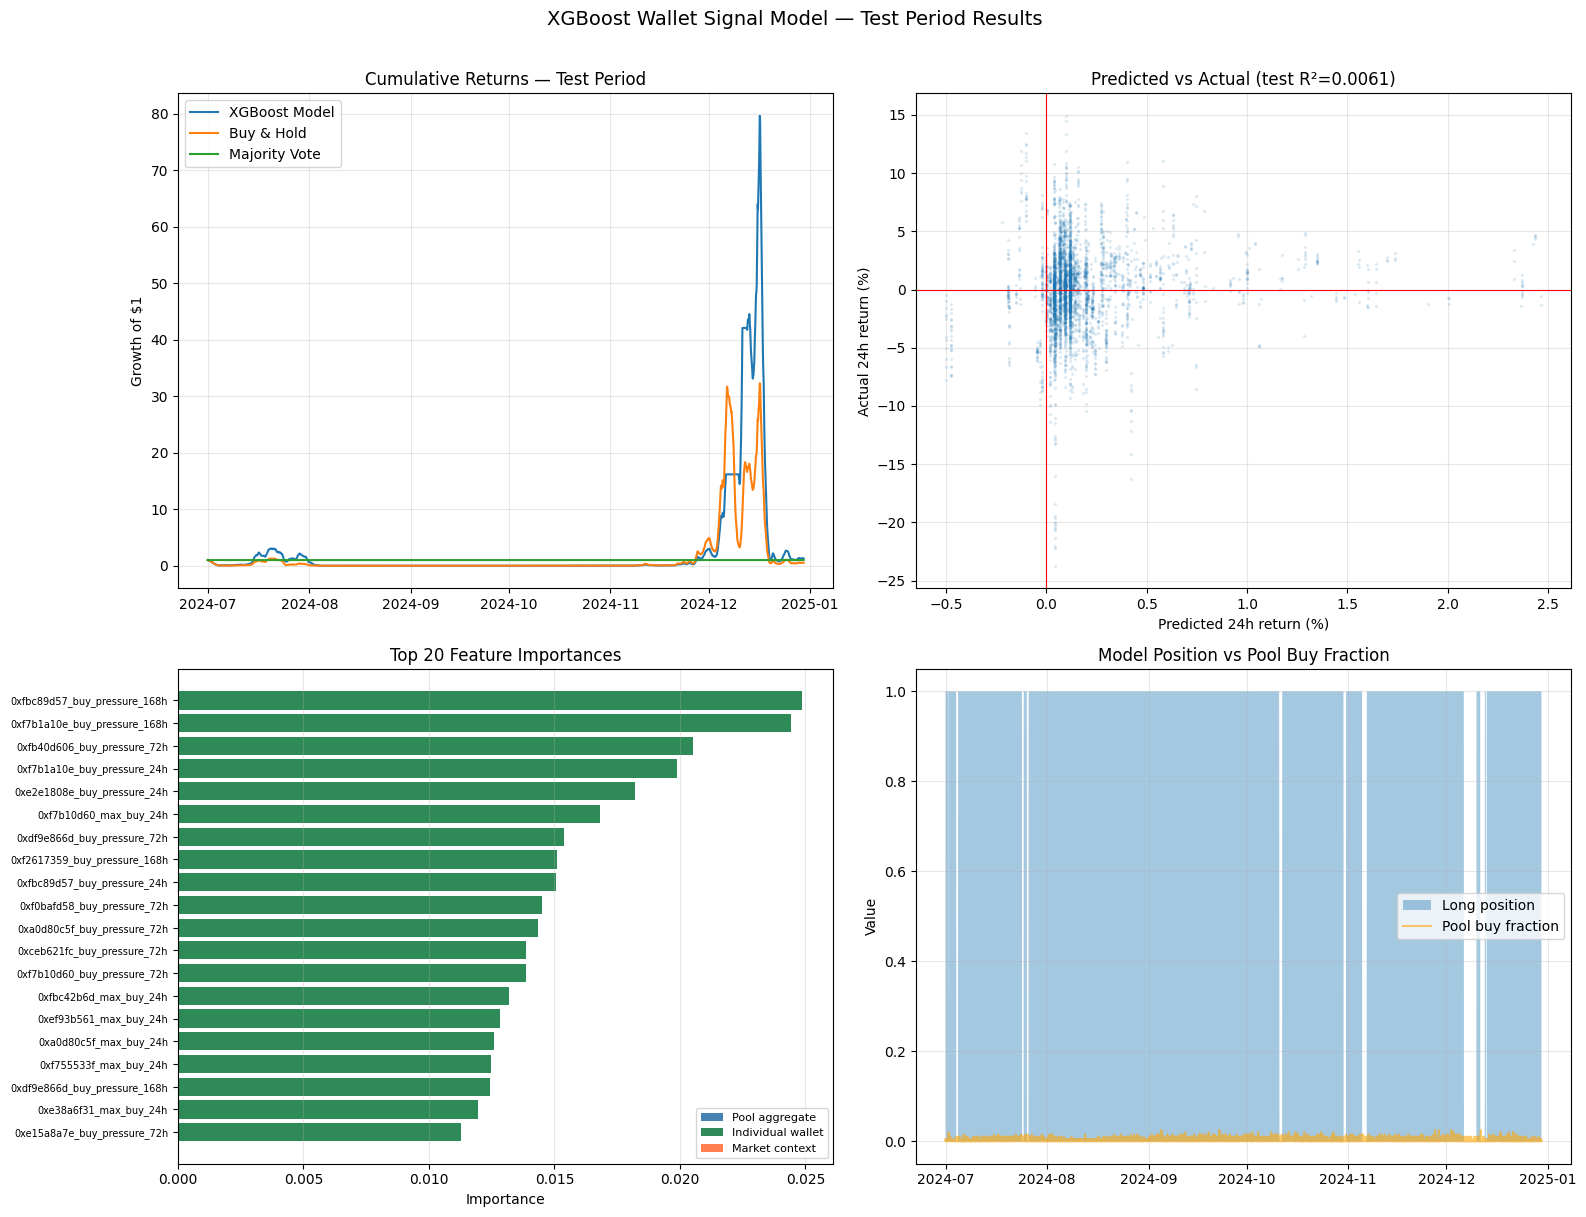

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Cumulative returns comparison
ax = axes[0, 0]
for label, pos in [
    ('XGBoost Model', test_df['position'].values),
    ('Buy & Hold',    bah_pos),
    ('Majority Vote', mv_pos),
]:
    cum = (1 + pos * test_ret / 100).cumprod()
    ax.plot(test_df['timestamp'].values, cum, label=label)
ax.set_title('Cumulative Returns — Test Period')
ax.set_ylabel('Growth of $1')
ax.legend()
ax.grid(alpha=0.3)

# 2. Predicted vs actual returns (scatter)
ax = axes[0, 1]
ax.scatter(y_pred_test, y_test, alpha=0.1, s=2)
ax.axhline(0, color='red', linewidth=0.8)
ax.axvline(0, color='red', linewidth=0.8)
ax.set_xlabel('Predicted 24h return (%)')
ax.set_ylabel('Actual 24h return (%)')
ax.set_title(f'Predicted vs Actual (test R²={r2_score(y_test, y_pred_test):.4f})')
ax.grid(alpha=0.3)

# 3. Feature importance — top 20
ax = axes[1, 0]
top20 = importance_df.head(20)
colors = {'Pool aggregate': 'steelblue', 'Individual wallet': 'seagreen', 'Market context': 'coral'}
bar_colors = [colors.get(c, 'gray') for c in top20['category']]
ax.barh(range(len(top20)), top20['importance'].values, color=bar_colors)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels([f[:30] for f in top20['feature']], fontsize=7)
ax.invert_yaxis()
ax.set_title('Top 20 Feature Importances')
ax.set_xlabel('Importance')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors.items()]
ax.legend(handles=legend_elements, fontsize=8)
ax.grid(alpha=0.3, axis='x')

# 4. Position distribution over time
ax = axes[1, 1]
ax.fill_between(test_df['timestamp'].values,
                test_df['position'].values, alpha=0.4, label='Long position')
ax.plot(test_df['timestamp'].values,
        test_df['pool_buy_fraction'].values, alpha=0.6, color='orange', label='Pool buy fraction')
ax.set_title('Model Position vs Pool Buy Fraction')
ax.set_ylabel('Value')
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle('XGBoost Wallet Signal Model — Test Period Results', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 12. Save results

In [27]:
# Save results
test_df[['timestamp', 'close', 'fwd_return', 'predicted_return',
         'position', 'pool_buy_fraction', 'pool_skill_wtd_signal']].to_csv(
    MODEL_RESULTS_CSV, index=False
)

print(f"Model results saved: {MODEL_RESULTS_CSV}")
print()
print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"Model directional accuracy (test): {test_dir:.3f}")
print(f"Model Sharpe (annualized):         {model_stats['sharpe_annualized']:.3f}")
print(f"Model total return:                {model_stats['total_return_pct']:.2f}%")
print(f"Model max drawdown:                {model_stats['max_drawdown_pct']:.2f}%")
print(f"% time in market:                  {model_stats['pct_long']:.1f}%")
print()
print(f"Buy & Hold Sharpe:                 {bah_stats['sharpe_annualized']:.3f}")
print(f"Buy & Hold total return:           {bah_stats['total_return_pct']:.2f}%")
print(f"Buy & Hold max drawdown:           {bah_stats['max_drawdown_pct']:.2f}%")
print()
print(f"Wallet signal importance:          {wallet_importance:.1%}")
print(f"Market context importance:         {market_importance:.1%}")


Model results saved: /home/colin/projects/blockchain_alpha/data/model_results.csv

FINAL SUMMARY
Model directional accuracy (test): 0.526
Model Sharpe (annualized):         1.714
Model total return:                29.51%
Model max drawdown:                -99.99%
% time in market:                  94.5%

Buy & Hold Sharpe:                 1.235
Buy & Hold total return:           -47.49%
Buy & Hold max drawdown:           -100.00%

Wallet signal importance:          97.8%
Market context importance:         2.2%


# See the project brief log for more of a summary.  This again proves the core thesis, using these wallet behavioral signals provides real edge vs a buy and hold strategy, with most of the value coming from individual wallet time horizion feature based signals.

In [28]:
# lets look at the buying for that one exceptional wallet

In [29]:
import requests
import pandas as pd
from datetime import datetime

ALCHEMY_API_KEY = "8J0Ou3_XsuWVbOiZ0xpEvioGx7k0wab9"
wallet = '0x1b4b91bb747176451f0f7f73b636babafcf31cc4'

def get_eth_balance_at_block(address, block='latest'):
    payload = {
        "jsonrpc": "2.0",
        "method": "eth_getBalance",
        "params": [address, hex(block) if isinstance(block, int) else block],
        "id": 1
    }
    resp = requests.post(
        f"https://eth-mainnet.g.alchemy.com/v2/{ALCHEMY_API_KEY}",
        json=payload, timeout=10
    )
    return int(resp.json()['result'], 16) / 1e18

def get_recent_transfers(address, days=30):
    """Pull recent ETH transfers for the wallet."""
    payload = {
        "jsonrpc": "2.0",
        "method": "alchemy_getAssetTransfers",
        "params": [{
            "fromAddress": address,
            "category": ["external", "internal"],
            "withMetadata": True,
            "maxCount": "0x64",  # 100
            "order": "desc"
        }],
        "id": 1
    }
    resp = requests.post(
        f"https://eth-mainnet.g.alchemy.com/v2/{ALCHEMY_API_KEY}",
        json=payload, timeout=15
    )
    transfers_out = resp.json().get('result', {}).get('transfers', [])

    payload['params'][0] = {
        "toAddress": address,
        "category": ["external", "internal"],
        "withMetadata": True,
        "maxCount": "0x64",
        "order": "desc"
    }
    resp = requests.post(
        f"https://eth-mainnet.g.alchemy.com/v2/{ALCHEMY_API_KEY}",
        json=payload, timeout=15
    )
    transfers_in = resp.json().get('result', {}).get('transfers', [])

    return transfers_out, transfers_in

# Current balance
current_balance = get_eth_balance_at_block(wallet)
print(f"Wallet: {wallet}")
print(f"Current ETH balance: {current_balance:.4f} ETH")
print()

# Recent transfers
transfers_out, transfers_in = get_recent_transfers(wallet)

# Combine and sort
rows = []
for t in transfers_out:
    rows.append({
        'timestamp': t['metadata']['blockTimestamp'],
        'direction': 'OUT',
        'value_eth': float(t.get('value', 0) or 0),
        'hash': t['hash']
    })
for t in transfers_in:
    rows.append({
        'timestamp': t['metadata']['blockTimestamp'],
        'direction': 'IN',
        'value_eth': float(t.get('value', 0) or 0),
        'hash': t['hash']
    })

df = pd.DataFrame(rows)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp', ascending=False).reset_index(drop=True)

# Net daily delta
df['date'] = df['timestamp'].dt.date
df['signed_eth'] = df.apply(
    lambda r: r['value_eth'] if r['direction'] == 'IN' else -r['value_eth'],
    axis=1
)

daily = df.groupby('date').agg(
    net_delta   = ('signed_eth', 'sum'),
    n_transfers = ('signed_eth', 'count'),
    total_in    = ('signed_eth', lambda x: x[x>0].sum()),
    total_out   = ('signed_eth', lambda x: x[x<0].abs().sum()),
).sort_index(ascending=False).reset_index()

print("Recent daily activity:")
print(daily.head(30).to_string(index=False))
print()

# Flag high conviction moves
high_conv = daily[daily['net_delta'].abs() >= 1.0]
if len(high_conv) > 0:
    print(f"⚡ HIGH CONVICTION MOVES (>=1 ETH net delta):")
    print(high_conv.to_string(index=False))
else:
    print("No high conviction moves (>=1 ETH) in recent history.")
    print(f"Last DCA activity: {daily[daily['net_delta'].abs() > 0]['date'].iloc[0]}")

Wallet: 0x1b4b91bb747176451f0f7f73b636babafcf31cc4
Current ETH balance: 0.0020 ETH

Recent daily activity:
      date  net_delta  n_transfers  total_in  total_out
2026-04-19   0.001843            2  0.122074   0.120231
2026-04-14  -0.001589            6  0.328427   0.330016
2026-04-13  -0.007954           10  0.032875   0.040829
2026-04-12   0.010311           23  1.035712   1.025401
2026-04-11  -0.000331           10  0.543683   0.544014
2026-04-09  -0.001255            2  0.007796   0.009051
2026-04-06  -0.010699            2  0.069880   0.080579
2026-04-05   0.003908            2  0.038908   0.035000
2026-04-04  -0.355816           96  2.788761   3.144576
2026-04-01  -0.090092            1  0.000000   0.090092
2026-03-18  -0.087693            2  0.000000   0.087693
2026-03-13  -0.005089            1  0.000000   0.005089
2026-03-03  -0.400263            1  0.000000   0.400263
2026-03-01  -0.250516            1  0.000000   0.250516
2026-02-24  -0.110686            1  0.000000   0.1106